Εισαγωγη εικόνων


In [ ]:
from PIL import Image
import numpy as np
from google.colab import drive
from typing import Dict

# Mount Google Drive
drive.mount('/content/drive')

# File paths
drive_path = "/content/drive/MyDrive/Colab Notebooks/input_img.jpg"
drive_path2 = "/content/drive/MyDrive/Colab Notebooks/ref_img.jpg"

# Load and convert to grayscale
input_img = Image.open(drive_path).convert("L")
ref_img = Image.open(drive_path2).convert("L")

# Convert to float arrays normalized to [0, 1]
input_array = np.array(input_img).astype(np.float32) / 255.0
ref_array = np.array(ref_img).astype(np.float32) / 255.0

print("✅ Input image shape:", input_array.shape)
print("✅ Reference image shape:", ref_array.shape)


Mounted at /content/drive
✅ Input image shape: (890, 1187)
✅ Reference image shape: (540, 720)


Υπολογισμός του dictionary της εικόνας

In [ ]:
def calculate_hist_of_img(img_array: np.ndarray, return_normalized: bool) -> Dict:
    """Υπολογισμός ιστογράμματος από πίνακα εικόνας."""
    unique, counts = np.unique(img_array, return_counts=True)
    hist = dict(zip(unique, counts))

    if return_normalized:
        total = sum(counts)
        return {k: v/total for k, v in hist.items()}
    return hist

Συνάρτηση που δέχεται την εικόνα εισόδου και πραγματοποιεί την απεικόνιση μέσω του δοθέντα μετασχηματισμού modification.

In [ ]:
import numpy as np
from typing import Dict

def apply_hist_modification_transform(image_array, transform_dict):
    # Ensure input is in [0, 1]
    image_array = np.clip(image_array, 0.0, 1.0)

    # Scale to 0-255
    scaled_image = (image_array * 255).astype(np.uint8)

    # Lookup table
    lut = np.array([transform_dict.get(np.float32(i / 255.0), 0.0) for i in range(256)], dtype=np.float32)


    # Apply LUT
    output_array = lut[scaled_image]

    print("LUT:", lut[:10])  # Δείξε μου τις πρώτες τιμές
    print("LUT dtype:", lut.dtype)

    print("scaled_image dtype:", scaled_image.dtype)
    print("scaled_image min/max:", scaled_image.min(), scaled_image.max())

    output_array = lut[scaled_image]
    print("output_array min/max:", output_array.min(), output_array.max())
    print("output_array unique:", np.unique(output_array))

    return output_array

"""def apply_hist_modification_transform(image_array, transform_dict):
    scaled_image = (image_array * 255).astype(np.uint8)
    lut = np.array([transform_dict.get(i, 0.0) for i in range(256)])
    return lut[scaled_image]"""



# Εφαρμογή του greedy μετασχηματισμού στην εικόνα
modified_array = apply_hist_modification_transform(input_array, modification_transform)


NameError: name 'modification_transform' is not defined

Greedy εξισορρόπηση ιστογράμματος

In [ ]:
def greedy_hist_equalization(hist: Dict[int, int], L_out: int) -> Dict[int, int]:
    N = sum(hist.values())
    target_per_bin = N / L_out

    input_levels = sorted(hist.keys())
    transform = {}

    current_sum = 0
    current_output_level = 0

    for f_i in input_levels:
        current_sum += hist[f_i]
        transform[f_i] = current_output_level

        # Αυξάνουμε το output level όσο "γεμίζει"
        while current_sum >= target_per_bin and current_output_level < L_out - 1:
            current_sum -= target_per_bin
            current_output_level += 1

    return transform



In [ ]:
# 1. Quantize την εικόνα για υπολογισμό ιστογράμματος (σε ακέραιες τιμές 0–255)
input_quantized = (input_array * 255).astype(np.uint8)

# 2. Υπολογισμός ιστογράμματος με ακέραια bins
hist = calculate_hist_of_img(input_quantized, return_normalized=False)

# 3. Greedy εξισορρόπηση
modification_transform = greedy_hist_equalization(hist, L_out=256)

# 4. Εφαρμογή του μετασχηματισμού πάνω στην *quantized* εικόνα
# (Ή αν θες, μπορείς να κάνεις apply στην float εικόνα, δες σημείωση παρακάτω)
equalized_img = apply_hist_modification_transform(input_quantized, modification_transform)

# 5. (Προαιρετικό) Αν θες να δεις την equalized εικόνα ως float για εμφάνιση:
equalized_img_float = equalized_img.astype(np.float32) / 255.0


Non-greedy εξισορρόπηση ιστογράμματος

In [ ]:
import numpy as np
from typing import Dict

import numpy as np

import numpy as np

import numpy as np

def _non_greedy_mapping(hist: dict, Lg: int, threshold: float = 0.5) -> dict:
    """Non-greedy histogram mapping with threshold.

    Args:
        hist: Dictionary with {pixel_value: count}
        Lg: Number of output levels (e.g., 256 for 8-bit images)
        threshold: Deficiency threshold (default 0.5)

    Returns:
        Dictionary mapping {input_level: output_level} (normalized to [0,1])
    """
    # Convert numpy types to native Python types
    converted_hist = {float(k): int(v) for k, v in hist.items()}

    # Calculate total pixels
    N = sum(converted_hist.values())

    # Prepare mapping
    sorted_levels = sorted(converted_hist.keys())
    target = N / Lg
    mapping = {}
    current_bin = 0
    accumulated = 0

    for level in sorted_levels:
        count = converted_hist[level]
        deficiency = target - accumulated

        if deficiency >= count * threshold and current_bin < Lg - 1:
            mapping[level] = current_bin / (Lg - 1)
            accumulated += count
        else:
            current_bin = min(current_bin + 1, Lg - 1)
            mapping[level] = current_bin / (Lg - 1)
            accumulated = count

    return mapping

In [ ]:
def perform_hist_modification(img_array: np.ndarray,
                            hist_ref: Dict,
                            mode: str) -> np.ndarray:
    """Κύρια συνάρτηση τροποποίησης ιστογράμματος."""
    hist = calculate_hist_of_img(img_array, return_normalized=False)
    N = img_array.size

    if mode == "greedy":
        mapping = _greedy_mapping(hist, N, len(hist_ref))
    elif mode == "non-greedy":
        mapping = _non_greedy_mapping(hist, 256)
    elif mode == "post-disturbance":
        mapping = _post_disturbance_mapping(img_array, hist_ref)

    return apply_hist_modification_transform(img_array, mapping)

In [ ]:
def perform_hist_eq(img_array: np.ndarray, mode: str, Lg: int = 256) -> np.ndarray:
    """
    Εξισορρόπηση ιστογράμματος εικόνας με επιλογή αλγορίθμου.

    Args:
        img_array: Εικόνα ως numpy array (float στο [0,1])
        mode: Τρόπος εξισορρόπησης ("greedy", "non-greedy", "post-disturbance")
        Lg: Αριθμός στάθμεων εξόδου (default 256)

    Returns:
        Εξισορροπημένη εικόνα (ίδιων διαστάσεων με την είσοδο)
    """
    target_hist = {i/(Lg-1): 1/Lg for i in range(Lg)}  # Ομοιόμορφο ιστόγραμμα
    return perform_hist_modification(img_array, target_hist, mode)

In [ ]:
def plot_comparison(original: np.ndarray, processed: np.ndarray, title: str):
    """Οπτικοποίηση σύγκρισης εικόνων και ιστογραμμάτων."""
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original, cmap='gray', vmin=0, vmax=1)
    plt.title("Αρχική Εικόνα")

    plt.subplot(1, 2, 2)
    plt.imshow(processed, cmap='gray', vmin=0, vmax=1)
    plt.title(title)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.hist(original.flatten(), bins=256, range=(0,1))
    plt.title("Αρχικό Ιστόγραμμα")

    plt.subplot(1, 2, 2)
    plt.hist(processed.flatten(), bins=256, range=(0,1))
    plt.title("Επεξεργασμένο Ιστόγραμμα")
    plt.show()

LUT: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
LUT dtype: float32
scaled_image dtype: uint8
scaled_image min/max: 0 255
output_array min/max: 0.0 0.0
output_array unique: [0.]


AttributeError: 'Image' object has no attribute 'flatten'

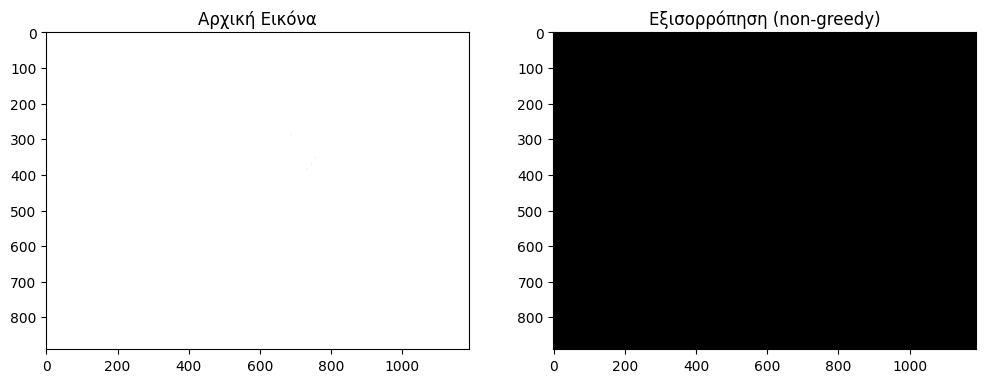

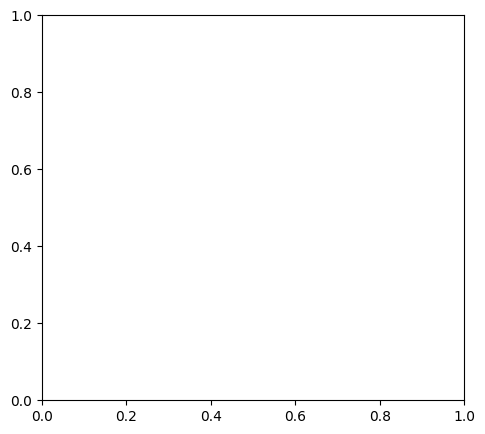

In [ ]:
import matplotlib.pyplot as plt

mode = "non-greedy"
equalized = perform_hist_eq(input_img, mode)
plot_comparison(input_img, equalized, f"Εξισορρόπηση ({mode})")

# Οπτικοποίηση
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.subplot(121); plt.imshow(input_array, cmap='gray'); plt.title("Original")
plt.subplot(122); plt.imshow(equalized, cmap='gray'); plt.title("Non-Greedy Equalized")
plt.show()
plot_histograms(input_array, equalized)

Οπτικοποίηση ιστογραμμάτων


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple


def plot_histograms(original_array: np.ndarray,
                              equalized_array: np.ndarray,
                              bins: int = 256,
                              density: bool = True) -> Tuple[plt.Figure, plt.Axes]:
    """
    Οπτικοποιεί ιστογράμματα από πίνακες pixel values.

    Παράμετροι:
        original_array: Πίνακας της αρχικής εικόνας (normalized [0,1])
        equalized_array: Πίνακας της εξισορροπημένης εικόνας (normalized [0,1])
        bins: Αριθμός bins για τα ιστογράμματα
        density: Αν True, κανονικοποιεί τις συχνότητες

    Επιστρέφει:
        Tuple με figure και axes objects
    """
    # Έλεγχος εισόδου
    assert original_array.ndim == 2, "Ο πίνακας πρέπει να είναι 2D"
    assert np.all(original_array >= 0) and np.all(original_array <= 1), "Τιμές εκτός [0,1]"

    # Δημιουργία γραφήματος
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Αρχικό ιστόγραμμα
    ax1.hist(original_array.flatten(), bins=bins, range=(0, 1),
            density=density, color='blue', alpha=0.7)
    ax1.set(title='Αρχικό Ιστόγραμμα',
           xlabel='Τιμή Pixel',
           ylabel='Σχετική Συχνότητα' if density else 'Πλήθος')
    ax1.grid(True, linestyle='--', alpha=0.3)

    # Εξισορροπημένο ιστόγραμμα
    ax2.hist(equalized_array.flatten(), bins=bins, range=(0, 1),
            density=density, color='green', alpha=0.7)
    ax2.set(title='Εξισορροπημένο Ιστόγραμμα',
           xlabel='Τιμή Pixel')
    ax2.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    return fig, (ax1, ax2)


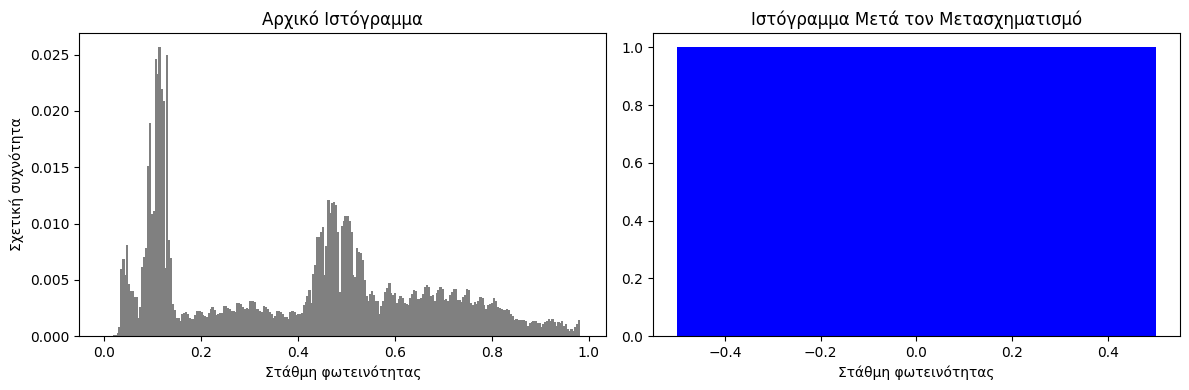

Input bin 0 → Output bin 0
Input bin 2 → Output bin 0
Input bin 4 → Output bin 0
Input bin 6 → Output bin 0
Input bin 8 → Output bin 0
Input bin 10 → Output bin 1
Input bin 12 → Output bin 5
Input bin 14 → Output bin 8
Input bin 16 → Output bin 10
Input bin 18 → Output bin 12
Input bin 20 → Output bin 13
Input bin 22 → Output bin 16
Input bin 24 → Output bin 22
Input bin 26 → Output bin 30
Input bin 28 → Output bin 39
Input bin 30 → Output bin 51
Input bin 32 → Output bin 62
Input bin 34 → Output bin 70
Input bin 36 → Output bin 74
Input bin 38 → Output bin 75
Input bin 40 → Output bin 76
Input bin 42 → Output bin 77
Input bin 44 → Output bin 78
Input bin 46 → Output bin 79
Input bin 48 → Output bin 80
Input bin 50 → Output bin 81
Input bin 52 → Output bin 82
Input bin 54 → Output bin 83
Input bin 56 → Output bin 84
Input bin 58 → Output bin 85
Input bin 60 → Output bin 86
Input bin 62 → Output bin 87
Input bin 64 → Output bin 89
Input bin 66 → Output bin 90
Input bin 68 → Output bin 9

In [ ]:
plot_histograms(input_array, equalized_img)

for i in range(0, 256, 2):
    # Check if the key exists before accessing it
    if i in modification_transform:
        print(f"Input bin {i} → Output bin {modification_transform[i]}")
    else:
        print(f"Input bin {i} → Not found in modification transform")

non_zero_bins = {k: v for k, v in hist.items() if v > 0}
print("Non-zero bins in hist:")
for k in sorted(non_zero_bins)[:20]:
    print(f"  Bin {k}: {non_zero_bins[k]}")

print("Min τιμή στην εικόνα:", input_array.min())
print("Max τιμή στην εικόνα:", input_array.max())



In [ ]:
import matplotlib.pyplot as plt

def show_images(original, modified):
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(original, cmap='gray')
    plt.title("Αρχική")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(modified, cmap='gray')
    plt.title("Μετά τον Greedy")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Θυμίσου: modified_array είναι σε [0,1]
show_images(input_array, modified_array)


NameError: name 'modified_array' is not defined

In [ ]:
import numpy as np
from typing import Dict

def perform_hist_modification(img_array: np.ndarray, hist_ref: Dict, mode: str) -> np.ndarray:
    if mode != "greedy":
        raise NotImplementedError("Only 'greedy' mode is implemented in this version.")

    # Αρχικά μετατρέπουμε την εικόνα σε flat πίνακα
    flat_img = img_array.flatten()

    # Κανονικοποιούμε την εικόνα στο [0, 1]
    flat_img = np.clip(flat_img, 0, 1)

    # Ορίζουμε πόσες στάθμες θέλουμε στην έξοδο
    Lg = len(hist_ref)
    N = len(flat_img)
    target_count = N // Lg

    # Βρίσκουμε το ιστόγραμμα και τις μοναδικές τιμές της εισόδου
    input_levels, counts = np.unique(flat_img, return_counts=True)

    # Ταξινόμηση βάσει τιμών (σε περίπτωση που δεν είναι ήδη)
    sorted_indices = np.argsort(input_levels)
    input_levels = input_levels[sorted_indices]
    counts = counts[sorted_indices]

    # Δημιουργούμε τον πίνακα με τις νέες στάθμες εξόδου
    output_levels = np.linspace(0, 1, Lg)

    # Δημιουργούμε έναν πίνακα με το νέο mapping
    mapping = np.zeros_like(flat_img)

    idx = 0
    cumulative = 0
    current_output_idx = 0
    assign_indices = []

    sorted_flat_indices = np.argsort(flat_img)
    sorted_flat_img = flat_img[sorted_flat_indices]

    for i in range(N):
        assign_indices.append(sorted_flat_indices[i])
        cumulative += 1

        if cumulative >= target_count or i == N - 1:
            # Αντιστοίχιση των επιλεγμένων δειγμάτων στην τρέχουσα στάθμη εξόδου
            for index in assign_indices:
                mapping[index] = output_levels[current_output_idx]
            assign_indices = []
            cumulative = 0
            current_output_idx += 1
            if current_output_idx >= Lg:
                current_output_idx = Lg - 1  # τυχόν "υπερχείλιση" την "κλείνουμε" στην τελευταία στάθμη

    # Επαναφορά στο αρχικό σχήμα της εικόνας
    modified_img = mapping.reshape(img_array.shape)

    return modified_img


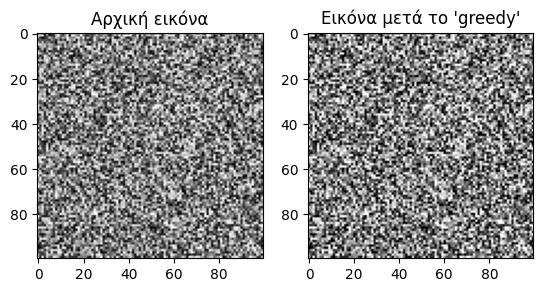

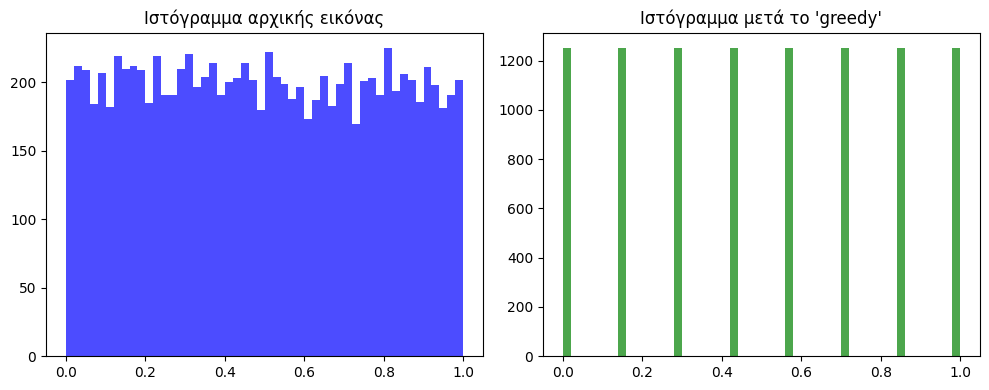

In [ ]:
import matplotlib.pyplot as plt

# Φανταστική grayscale εικόνα (παράδειγμα)
img = np.random.rand(100, 100)

# Επιθυμητό ιστόγραμμα: ομοιόμορφο σε 8 στάθμες
hist_ref = {i: 1/8 for i in range(8)}

# Κλήση της συνάρτησης
new_img = perform_hist_modification(img, hist_ref, mode="greedy")

# Εμφάνιση
plt.subplot(1, 2, 1)
plt.title("Αρχική εικόνα")
plt.imshow(img, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Εικόνα μετά το 'greedy'")
plt.imshow(new_img, cmap='gray')
plt.show()


plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(img.flatten(), bins=50, range=(0, 1), color='blue', alpha=0.7)
plt.title("Ιστόγραμμα αρχικής εικόνας")

plt.subplot(1, 2, 2)
plt.hist(new_img.flatten(), bins=50, range=(0, 1), color='green', alpha=0.7)
plt.title("Ιστόγραμμα μετά το 'greedy'")

plt.tight_layout()
plt.show()


In [ ]:

# Apply greedy equalization
equalized_img = greedy_histogram_equalization(input_array)

# Display results
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.subplot(121); plt.imshow(input_array, cmap='gray'); plt.title("Original")
plt.subplot(122); plt.imshow(equalized_img, cmap='gray'); plt.title("Equalized")
plt.show()

from typing import Dict

# Enable inline plotting in Colab
%matplotlib inline

def calculate_hist_of_img(img_array: np.ndarray, return_normalized: bool) -> Dict:
    hist = {}

    # Flatten the image array για ευκολότερη επεξεργασία
    flat_pixels = img_array.flatten()

    # Βρες τις μοναδικές τιμές (στάθμες) και πόσες φορές εμφανίζεται η καθεμία
    unique_vals, counts = np.unique(flat_pixels, return_counts=True)

    # Δημιουργία λεξικού: στάθμη -> count
    for val, count in zip(unique_vals, counts):
        if return_normalized:
            hist[val] = count / flat_pixels.size  # σχετική συχνότητα
        else:
            hist[val] = count  # απόλυτο πλήθος
    return hist


hist = calculate_hist_of_img(img_array=equalized_img, return_normalized=True)

# Plot histogram
bars = plt.bar(hist.keys(), hist.values(),
               width=0.01,
               color='blue',
               alpha=0.7,
               edgecolor='black')

# Customize plot
plt.title("Image Histogram (Normalized)", fontsize=14)
plt.xlabel("Pixel Value (Normalized to [0, 1])", fontsize=12)
plt.ylabel("Frequency", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Ensure tight layout
plt.tight_layout()

# Explicitly show the plot
plt.show()

NameError: name 'greedy_histogram_equalization' is not defined

In [ ]:

from typing import Dict
import matplotlib.pyplot as plt

# Enable inline plotting in Colab
%matplotlib inline

def calculate_hist_of_img(img_array: np.ndarray, return_normalized: bool) -> Dict:
    hist = {}

    # Flatten the image array για ευκολότερη επεξεργασία
    flat_pixels = img_array.flatten()

    # Βρες τις μοναδικές τιμές (στάθμες) και πόσες φορές εμφανίζεται η καθεμία
    unique_vals, counts = np.unique(flat_pixels, return_counts=True)

    # Δημιουργία λεξικού: στάθμη -> count
    for val, count in zip(unique_vals, counts):
        if return_normalized:
            hist[val] = count / flat_pixels.size  # σχετική συχνότητα
        else:
            hist[val] = count  # απόλυτο πλήθος
    return hist


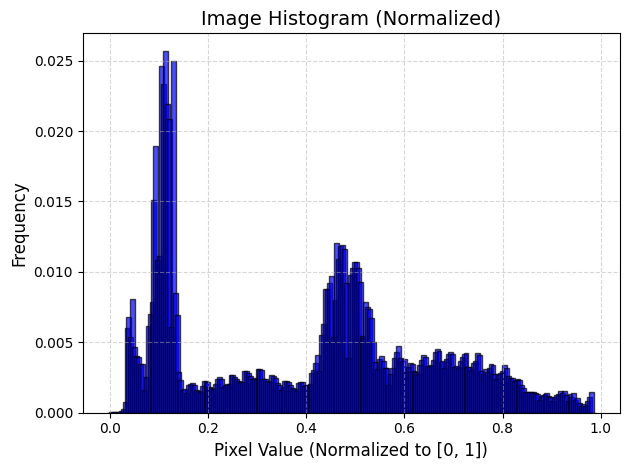

In [ ]:
hist = calculate_hist_of_img(img_array=input_array, return_normalized=True)

# Plot histogram
bars = plt.bar(hist.keys(), hist.values(),
               width=0.01,
               color='blue',
               alpha=0.7,
               edgecolor='black')

# Customize plot
plt.title("Image Histogram (Normalized)", fontsize=14)
plt.xlabel("Pixel Value (Normalized to [0, 1])", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Ensure tight layout
plt.tight_layout()

# Explicitly show the plot
plt.show()

In [ ]:
img = np.array([
    [0.0, 0.5, 0.5],
    [1.0, 0.0, 0.5]
])

print(calculate_hist_of_img(img, return_normalized=False))
# Έξοδος: {0.0: 2, 0.5: 3, 1.0: 1}

print(calculate_hist_of_img(img, return_normalized=True))
# Έξοδος: {0.0: 2/6, 0.5: 3/6, 1.0: 1/6}


{np.float64(0.0): np.int64(2), np.float64(0.5): np.int64(3), np.float64(1.0): np.int64(1)}
{np.float64(0.0): np.float64(0.3333333333333333), np.float64(0.5): np.float64(0.5), np.float64(1.0): np.float64(0.16666666666666666)}


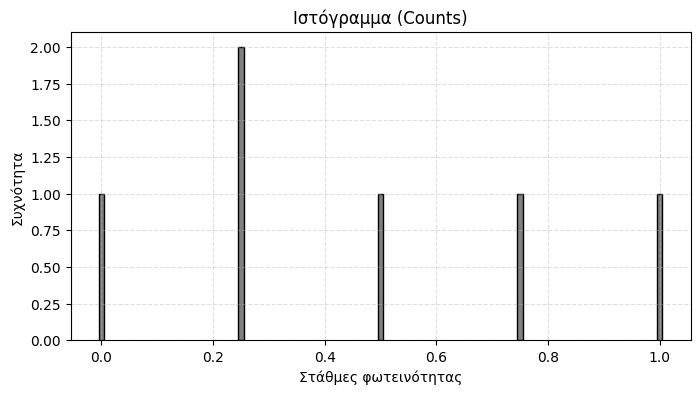

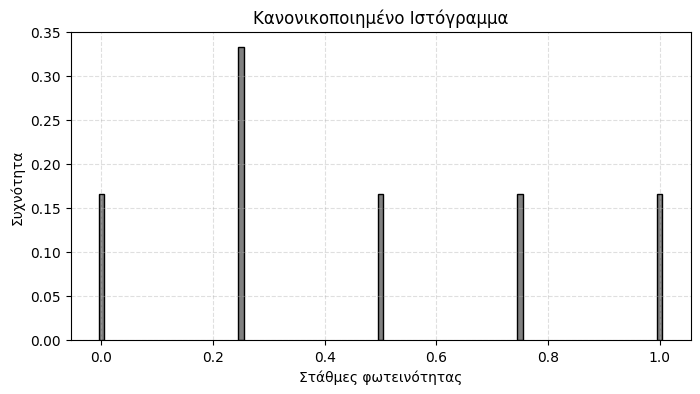

In [ ]:
import matplotlib.pyplot as plt

def plot_hist(hist: Dict, title: str = "Ιστόγραμμα"):
    x = list(hist.keys())
    y = list(hist.values())

    plt.figure(figsize=(8, 4))
    plt.bar(x, y, width=0.01, color='gray', edgecolor='black')
    plt.title(title)
    plt.xlabel("Στάθμες φωτεινότητας")
    plt.ylabel("Συχνότητα")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.show()


# Φανταστική εικόνα
img = np.array([
    [0.0, 0.25, 0.25],
    [0.5, 0.75, 1.0]
])

# Υπολογισμός ιστογράμματος
hist = calculate_hist_of_img(img, return_normalized=False)
plot_hist(hist, "Ιστόγραμμα (Counts)")

hist_norm = calculate_hist_of_img(img, return_normalized=True)
plot_hist(hist_norm, "Κανονικοποιημένο Ιστόγραμμα")
